# Direct Detection

In [151]:
# Library imports and params
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy import interpolate

# Defining the fonts before plotting:

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "monospace",  # Use monospace font
    "text.latex.preamble": r"\usepackage{courier}"  # Use Courier font
})
mpl.rcParams.update(mpl.rcParamsDefault)

plt.rcParams.update({
    'font.family': 'monospace',  # monospace font
    "text.latex.preamble": r"\usepackage{courier}",
    'font.size': 25,
    'axes.titlesize': 25,
    'axes.labelsize': 25,
    'xtick.labelsize': 25,
    'ytick.labelsize': 25,
    'legend.fontsize': 25,
    'figure.titlesize': 25,
})


In [152]:
### Constants and fixed parameters, carried over from Relic_Abundance.ipynb.

alpha = 1/137
alphaD = 0.1

mchi_over_ma = 0.6

OmegaDM = 0.265        # without the reduced Hubble constant factor

mp = 0.93827208816     # proton mass in GeV
me = 0.51099895e-3     # electron mass in GeV

### A xenon nucleus, and the momentum transfer a xenon recoil actually
### carries: q = sqrt(2 m_Xe E_R) at E_R = 10 keV, the middle of the search
### window, is 49 MeV. The mediator propagator can only be replaced by
### 1/m_A'^4 while m_A' is well above that.

mXe = 122.30           # 131 Xe nucleus mass in GeV
ER_ref = 1e-5          # reference nuclear recoil energy, 10 keV
q_ref_n = np.sqrt(2*mXe*ER_ref)

### For electron recoils the momentum transfer is set by the bound electron
### wavefunction instead, q ~ alpha m_e = 3.7 keV. It is the reference point
### the tabulated sigma_e values are quoted at, so it is carried through the
### propagator rather than dropped: that way the cross section is the same
### expression in both mediator regimes and assumes nothing about F_DM.

q_ref_e = alpha*me

cm2_to_GeVm2 = 2.5681894616e27          # 1 cm^2 = (hbar c)^-2 GeV^-2

### The direct detection limits are algebraic, so they get their own dense
### grid rather than the relic line's; it runs well past the relic file
### because XENONnT and LZ only constrain mchi >= 3 and 9 GeV, i.e.
### m_A' >= 5 and 15 GeV at this mass ratio.

ma_dd = np.logspace(np.log10(1e-2), np.log10(1e2), 4000)
mchi_dd = mchi_over_ma*ma_dd


In [153]:
### The relic line from moller_scan.py: the Gondolo-Gelmini thermal average
### solved for the epsilon that reproduces Omega_DM, cached so this notebook
### never has to re-run the scan.

def read_relic_csv(path):
    """Read a moller_scan.py CSV, returning (ma, eps, metadata dict)."""
    meta = {}
    with open(path) as fh:
        for line in fh:
            if not line.startswith("#"):
                break
            for field in line.lstrip("# ").split(","):
                if "=" in field:
                    key, val = field.split("=", 1)
                    meta[key.strip()] = val.strip()

    # np.genfromtxt takes the first line as the names even when it is a
    # comment, so the three header comments have to be skipped explicitly.
    data = np.genfromtxt(path, delimiter=",", names=True, skip_header=3)
    return data["MAp"], data["eps"], meta

### Kling's mass range, the file the scan was written for.

ma_relic, eps_relic, meta_relic = read_relic_csv("data/moller_relic_line.csv")

### The same scan carried out to 20 GeV, which is where the direct detection
### limits live; the two agree point for point where they overlap.

ma_relic_w, eps_relic_w, meta_relic_w = read_relic_csv(
    "data/moller_relic_line_wide.csv")

alphaD = float(meta_relic["alphaD"])
mchi_over_ma = float(meta_relic["mchi_over_ma"])
mchi_dd = mchi_over_ma*ma_dd


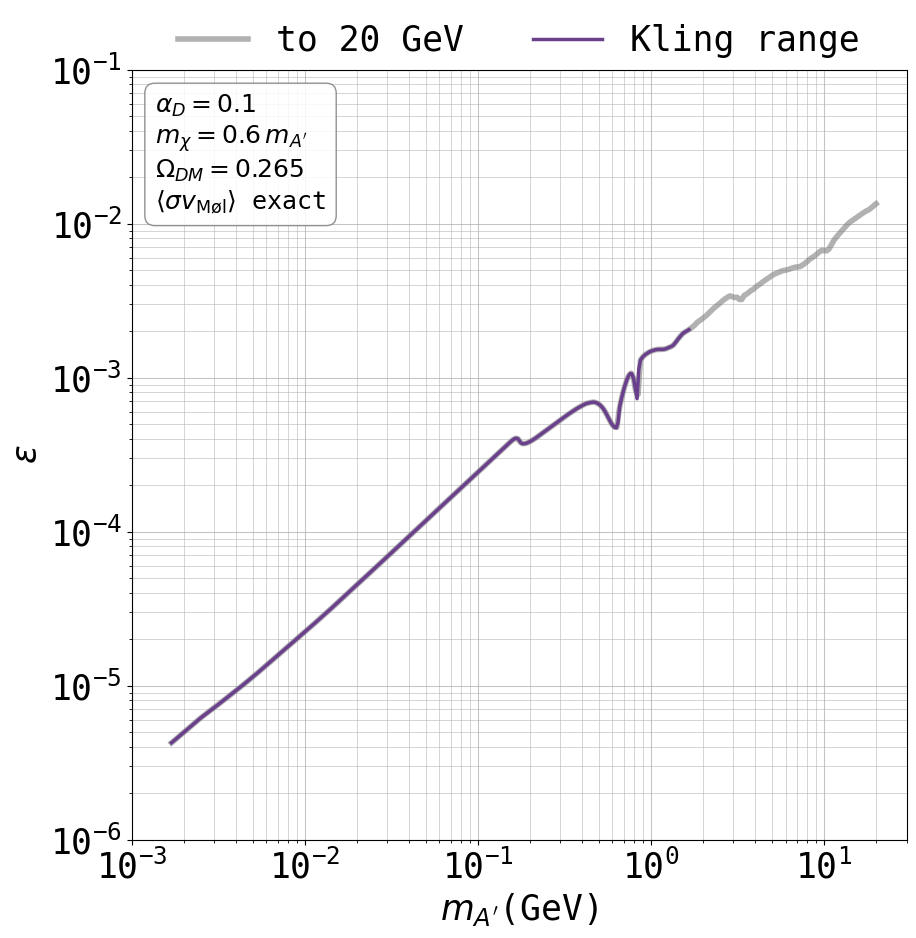

In [154]:
### Confirming the imported line before anything is built on top of it.

# Creating a plot:

fig, ax = plt.subplots(figsize=(10, 10))

ax.set_xlabel(r"$m_{A'}$(GeV)")
ax.set_ylabel(r"$\varepsilon$")

# Log Axis
ax.set_xscale('log')
ax.set_yscale('log')

# Major grid:
ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.75)

# Minor ticks and grid:
ax.minorticks_on()
ax.grid(True, which='minor', linestyle='-', linewidth=0.5, alpha=0.75)

ax.set_axisbelow(True) # Ensure grid is below data

ax.plot(ma_relic_w, eps_relic_w, color = '#7e7e7e', linewidth = 4.0,
        alpha = 0.6, label = r"to 20 GeV")
ax.plot(ma_relic, eps_relic, color = '#6a408d', linewidth = 2.5,
        label = r"Kling range")

ax.text(0.03, 0.97,
        "\n".join([r"$\alpha_D = %g$" % alphaD,
                   r"$m_\chi = %g\, m_{A'}$" % mchi_over_ma,
                   r"$\Omega_{DM} = %s$" % meta_relic["Omega_target"],
                   r"$\left\langle \sigma v_{\rm M\o l} \right\rangle$ exact"]),
        transform = ax.transAxes, va = 'top', ha = 'left', fontsize = 18,
        bbox = dict(boxstyle = 'round,pad=0.4', facecolor = 'white',
                    edgecolor = '#7e7e7e', alpha = 0.85))

# Setting a costumised legend:
handles, labels = ax.get_legend_handles_labels() # get all legend items
desired_order = range(len(handles))  # change the order of legend elements

ax.legend(
    [handles[i] for i in desired_order],
    [labels[i] for i in desired_order],
    loc = 'upper center',
    bbox_to_anchor = (0.5, 1.10),  # center top, above axes
    ncol = 2,                      # spread horizontally
    frameon = False                # removes legend border
)

ax.set_xbound(1e-3, 3e1)
ax.set_ybound(1e-6, 1e-1)

# Save and show the figure:
plt.savefig("figures/relic_line_moller_imported.pdf", bbox_inches='tight')
plt.show()


In [155]:
data_LZ_2024 = np.loadtxt("data/LZ2024_Limit.csv", delimiter=',')

mass_data_LZ_2024 = data_LZ_2024[:, 0]
sigmasidatacm2_LZ_2024 = data_LZ_2024[:, 1]

cm2_to_GeVm2 = 2.5681894616e27          # 1 cm^2 = (hbar c)^-2 GeV^-2
sigmasidataGeV_LZ_2024 = sigmasidatacm2_LZ_2024 * cm2_to_GeVm2

# Interpolating
dd_limit_fun_LZ2024 = interpolate.interp1d(mass_data_LZ_2024, sigmasidataGeV_LZ_2024)

### SI - Interaction cross section

$$
\sigma = \frac{16 \pi \epsilon^2 \alpha \alpha_D}{(\alpha^2 m_e^2 + m_{A'}^2)^2} \mu_{\chi e}
$$

where $\mu_{\chi e}$ is the reduced mass of the DM electron system.

In [156]:
### The theory side: the cross sections an experiment's limit is compared
### against. All three are the same dark photon exchange amplitude, differing
### only in the target and in how the propagator is treated.

def sig_si_theo(ma, alpha, alphaD, mchi, epsilon):
    """SI DM-nucleon cross section in the heavy mediator limit, in GeV^-2."""
    mu = mchi*mp/(mchi + mp)                                   # reduced mass
    return 16*np.pi * epsilon**2 * alpha * alphaD * mu**2 / ma**4

def sig_si_theo_ff(ma, alpha, alphaD, mchi, epsilon, q = None):
    """SI DM-nucleon cross section keeping the mediator propagator at finite q.

    The dark matter form factor F_DM(q) = m_A'^2/(m_A'^2 + q^2) multiplies the
    amplitude, so the cross section carries its square. It reduces to
    sig_si_theo for m_A' >> q and cuts the rate off as (m_A'/q)^4 below it.
    """
    q = q_ref_n if q is None else q
    mu = mchi*mp/(mchi + mp)                                   # reduced mass
    return (16*np.pi * epsilon**2 * alpha * alphaD * mu**2
            / (ma**2 + q**2)**2)

def sig_si_theo_elec(ma, alpha, alphaD, mchi, epsilon, q = None):
    """DM-electron cross section at momentum transfer q, in GeV^-2.

    Same amplitude with the electron as the target, so only the reduced mass
    changes, and the full propagator 1/(m_A'^2 + q^2)^2 is kept rather than
    either limit of it. That makes the expression valid on both sides of
    m_A' = q without assuming a dark matter form factor: it reduces to the
    contact 1/m_A'^4 for m_A' >> q and to the massless mediator 1/q^4 below
    it, with F_DM(q) = (m_A'^2 + q_ref^2)/(m_A'^2 + q^2) implied rather than
    imposed. q defaults to the reference transfer the limits are quoted at.
    """
    q = q_ref_e if q is None else q
    mu = mchi*me/(mchi + me)                                   # reduced mass
    return (16*np.pi * epsilon**2 * alpha * alphaD * mu**2
            / (ma**2 + q**2)**2)

### One helper instead of a per-experiment copy: every limit is the same
### comparison, sigma_theo(epsilon = 1) against a tabulated sigma.

def eps_dd_limit(ma, mchi, mass_tab, sigma_tab, sigma_theo = sig_si_theo,
                 alpha = alpha, alphaD = alphaD):
    """epsilon at which sigma_theo equals the tabulated limit at that mchi.

    Points whose mchi falls outside the tabulated mass range are dropped, so
    the limit is only drawn where the experiment actually constrains it.

    Returns (ma_valid, eps_valid).
    """
    ma, mchi = np.broadcast_arrays(np.atleast_1d(ma), np.atleast_1d(mchi))

    # Keep only the points the interpolator can evaluate:
    inside = (mchi >= mass_tab.min()) & (mchi <= mass_tab.max())
    ma, mchi = ma[inside], mchi[inside]

    # The tabulated limits span decades over few points, so they are read
    # off a log-log interpolation; a linear one overshoots between them.
    sigma_lim = np.exp(np.interp(np.log(mchi), np.log(mass_tab),
                                 np.log(sigma_tab)))
    return ma, np.sqrt(sigma_lim / sigma_theo(ma, alpha, alphaD, mchi, 1.0))

def eps_dd_limit_LZ2024(ma, alpha, alphaD, mchi):
    """epsilon at which sig_si_theo == the LZ 2024 limit at that mchi."""
    return eps_dd_limit(ma, mchi, mass_data_LZ_2024, sigmasidataGeV_LZ_2024,
                        alpha = alpha, alphaD = alphaD)


In [157]:
mlims, eplims =eps_dd_limit_LZ2024(ma_dd, alpha, alphaD, mchi_dd)

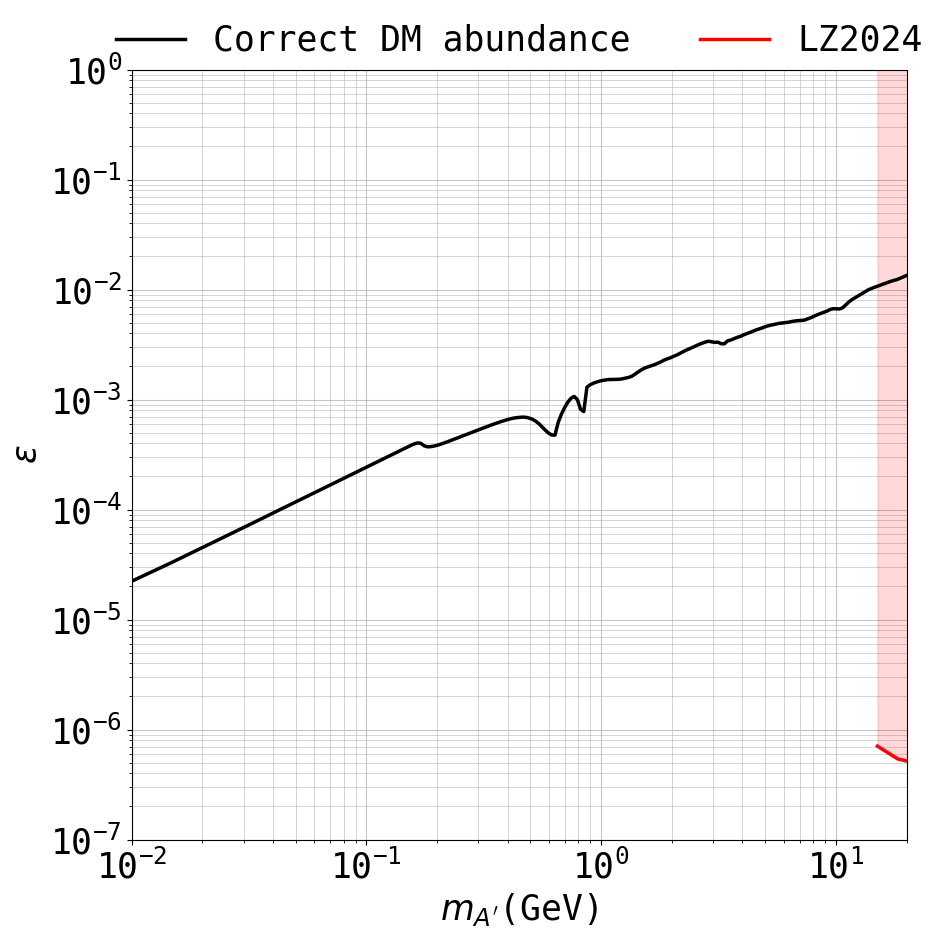

In [158]:
## Creating a plot:

fig, ax = plt.subplots(figsize=(10, 10))

ax.set_xlabel(r"$m_{A'}$(GeV)")
ax.set_ylabel(r"$\epsilon$")

## Log Axis
ax.set_xscale('log')
ax.set_yscale('log')

## Lock the square shape
#ax.set_aspect('equal', adjustable='datalim')

## Major grid:
ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.75)

## Minor ticks and grid:
ax.minorticks_on()
ax.grid(True, which='minor', linestyle='-', linewidth=0.5, alpha=0.75)

ax.set_axisbelow(True) # Ensure grid is below data

ax.plot(ma_relic_w, eps_relic_w, color = 'black', linewidth = 2.5,
        label = r"Correct DM abundance")

ax.plot(mlims, eplims, color = 'red', linewidth = 2.5, label = r"LZ2024")

ax.fill_between(mlims, eplims, 
                1,
                label= rf"Direct detection (Xenon1T)",
                color='red', 
                alpha=0.15, 
                zorder=1)

## Color palets:

dataset_colors = ['#9671bd', '#7e7e7e', '#77b5b6']
dataset_line_colors = ['#6a408d', '#4e4e4e', '#378d94']

# And the colour for the lines (regressions):
regression_color = '#8a8a8a' # <-- neutral grey
# regression_color = '#7f9fa1' # <-- greyish seafoam

'''

ax.scatter(final_data[:,0],final_data[:,1],
            label = "Correct DM abundance",
          s = 90,
          color = dataset_colors[0],
          edgecolors = dataset_line_colors[0],
          linewidths = 1.5,
          zorder = 3
    )

'''

## Setting a costumised legend:
handles, labels = ax.get_legend_handles_labels() # get all legend items
desired_order = [0,1]  # change the order of legend elements


ax.legend(
    [handles[i] for i in desired_order],
    [labels[i] for i in desired_order],
    loc = 'upper center',
    bbox_to_anchor = (0.5, 1.10),  # center top, above axes
    ncol = 4,                      # spread horizontally
    frameon = False                # removes legend border
)

# Define how much to zoom out from the data plotting range (cm):
x_min = 1e-2
x_max = 2e1
x_range = x_max - x_min

y_min = 1e-7
y_max = 1e0
y_range = y_max - y_min

# Set the new plotting limits explicitly
ax.set_xbound(x_min, x_max)
ax.set_ybound(y_min, y_max)


# Save and show the figure:
plt.savefig("figures/relic_abundance_0.pdf", bbox_inches='tight')
plt.show()

In [159]:
### XENONnT SR0+1 SI limit (FIG 3 A of arXiv:2409.17868), from the .npy points

limits_dir_XENONnT = ("data/XENONnT-light_wimp_data_release-64d2e13/"
                      "light_wimp_data_release/limits")

# The published limit is the power-constrained one; the folder also holds
# xenonnt_si_limit_before_pcl.npy and xenonnt_si_limit_after_dl_pcl.npy.
data_XENONnT_si = np.load(f"{limits_dir_XENONnT}/xenonnt_si_limit_after_pcl.npy")

mass_data_XENONnT_si = data_XENONnT_si['mass_gev']
sigmasidatacm2_XENONnT_si = data_XENONnT_si['limit_cm2']

sigmasidataGeV_XENONnT_si = sigmasidatacm2_XENONnT_si * cm2_to_GeVm2

# Interpolating: only 7 tabulated points spanning 5 decades in sigma, so a
# linear interpolation would overshoot by up to ~5x between the low-mass
# points. The limit is close to a straight line in log-log, so interpolate there.
log_dd_limit_XENONnT_si = interpolate.interp1d(np.log(mass_data_XENONnT_si),
                                               np.log(sigmasidataGeV_XENONnT_si))

def dd_limit_fun_XENONnT_si(mchi):
    return np.exp(log_dd_limit_XENONnT_si(np.log(mchi)))

In [160]:
def eps_dd_limit_XENONnT_si(ma, alpha, alphaD, mchi, sigma_theo = sig_si_theo):
    """epsilon at which sigma_theo == the XENONnT SR0+1 SI limit at that mchi.

    Same construction as eps_dd_limit_LZ2024, over the tabulated 3-12 GeV
    range. sigma_theo selects which of the three cross sections the measured
    limit is compared against.

    Returns (ma_valid, eps_valid).
    """
    return eps_dd_limit(ma, mchi, mass_data_XENONnT_si, sigmasidataGeV_XENONnT_si,
                        sigma_theo = sigma_theo, alpha = alpha, alphaD = alphaD)


In [161]:
mlims_XENONnT, eplims_XENONnT = eps_dd_limit_XENONnT_si(ma_dd, alpha, alphaD,
                                                       mchi_dd)

### The same limit read against the other two cross sections. Only the theory
### side changes, so the three curves differ by exactly the propagator and
### reduced mass factors between them.

mlims_XENONnT_ff, eplims_XENONnT_ff = eps_dd_limit_XENONnT_si(
    ma_dd, alpha, alphaD, mchi_dd, sigma_theo = sig_si_theo_ff)

mlims_XENONnT_e, eplims_XENONnT_e = eps_dd_limit_XENONnT_si(
    ma_dd, alpha, alphaD, mchi_dd, sigma_theo = sig_si_theo_elec)


In [162]:
### XENON1T 2018 SI limit, data/Xenon1T-2018-limit.txt.

# Two columns, mchi in GeV and sigma_SI in cm^2, 28 points over 5.9-1000 GeV.

data_XENON1T = np.loadtxt("data/Xenon1T-2018-limit.txt")

mass_data_XENON1T = data_XENON1T[:, 0]
sigmasidataGeV_XENON1T = data_XENON1T[:, 1] * cm2_to_GeVm2

mlims_XENON1T, eplims_XENON1T = eps_dd_limit(ma_dd, mchi_dd, mass_data_XENON1T,
                                             sigmasidataGeV_XENON1T)

mlims_XENON1T_ff, eplims_XENON1T_ff = eps_dd_limit(
    ma_dd, mchi_dd, mass_data_XENON1T, sigmasidataGeV_XENON1T,
    sigma_theo = sig_si_theo_ff)

### And LZ against the form factor cross section, for the same comparison.

mlims_ff, eplims_ff = eps_dd_limit(ma_dd, mchi_dd, mass_data_LZ_2024,
                                   sigmasidataGeV_LZ_2024,
                                   sigma_theo = sig_si_theo_ff)


## FORESEE results: starting point

In [163]:
### Kling's own direct detection bound, data/Kling/bounds_DD.txt.

# Already an exclusion contour in the (m_A', epsilon) plane rather than a
# sigma_SI(mchi) limit, so it needs no reinterpretation: it was drawn for the
# same model, alphaD = 0.1 and mchi = 0.6 m_A' (recovered from the relic file
# in the same folder). It is a closed polygon whose first and last vertices
# are pulled up to epsilon = 1, i.e. the region above the curve is excluded.

bounds_DD_kling = np.loadtxt("data/Kling/bounds_DD.txt")

ma_DD_kling  = bounds_DD_kling[:, 0]
eps_DD_kling = bounds_DD_kling[:, 1]

# The two vertical closure segments are an artefact of closing the polygon,
# so the boundary itself is drawn without them.
ma_DD_kling_line  = ma_DD_kling[1:-1]
eps_DD_kling_line = eps_DD_kling[1:-1]


In [164]:
### The pieces of Kling's combined direct detection contour,
### data/Kling/DD_separate/*.txt.

# Five files, each a published limit in its own units rather than an
# (m_A', epsilon) contour, so each has to be reinterpreted the same way the
# LZ and XENONnT limits are. Only XENON1T-Migdal is kept: it is the one whose
# reinterpretation lands on bounds_DD.txt (ratio to it 1.02 median, 0.92-1.1
# over most of the range). The other four are electron recoil sigma_e limits
# (XENON10, XENON10_heavy, XENON100_heavy) or an eV-mass absorption limit
# (Xenon1TS2Only). None of them ever falls below the combined line, so none
# sets any part of it: the closest, XENON10_heavy, tracks it within a factor
# 1.2-1.9 below m_A' = 0.05 GeV and then runs away to 1e3 times it by 1 GeV,
# with XENON100_heavy a further factor 4 above that. Both are superseded by
# Xenon10and100.csv, read in the cell below, which is modestly stronger than
# either but still does not bound the model.

# Two columns, mchi in GeV and sigma_SI in cm^2, 64 points over 0.10-4.9 GeV;
# a nucleon limit, so it uses the same sig_si_theo as the other SI datasets.

data_XENON1T_migdal = np.loadtxt("data/Kling/DD_separate/XENON1T-Migdal.txt")

mass_data_XENON1T_migdal = data_XENON1T_migdal[:, 0]
sigmasidataGeV_XENON1T_migdal = data_XENON1T_migdal[:, 1] * cm2_to_GeVm2

mlims_migdal, eplims_migdal = eps_dd_limit(ma_dd, mchi_dd,
                                           mass_data_XENON1T_migdal,
                                           sigmasidataGeV_XENON1T_migdal)


In [165]:
### The combined XENON10 + XENON100 electron recoil limit,
### data/Kling/DD_separate/Xenon10and100.csv.

# Two comma separated columns, mchi in MeV and sigma_e in cm^2, 43 points
# over 8.9 MeV - 2.99 GeV, most sensitive at mchi = 178 MeV. It supersedes
# the two per-experiment files in the same folder, XENON10_heavy.txt and
# XENON100_heavy.txt, which are left unread: over the range all three share
# it sits just below both (median 0.74 of XENON10, 0.59 of XENON100), which
# is what a combined limit should do.

# It does not bound this model, but unlike the other electron files it comes
# close enough to be worth drawing against Kling's contour, so it appears in
# both planes. Read against sig_si_theo_elec it comes within
# 1.02 of Kling's combined contour at m_A' = 0.037 GeV and tracks it within
# 1.02-1.31 from 0.015 to 0.037 GeV, but never crosses below it, and its
# closest approach to the relic line is a factor 2.46 at m_A' = 0.029 GeV.

MeV_to_GeV = 1e-3

data_xe10and100 = np.loadtxt("data/Kling/DD_separate/Xenon10and100.csv",
                             delimiter = ",")

mass_data_xe10and100 = data_xe10and100[:, 0]*MeV_to_GeV
sigmaedatacm2_xe10and100 = data_xe10and100[:, 1]
sigmaedataGeV_xe10and100 = sigmaedatacm2_xe10and100 * cm2_to_GeVm2

mlims_xe10and100, eplims_xe10and100 = eps_dd_limit(
    ma_dd, mchi_dd, mass_data_xe10and100, sigmaedataGeV_xe10and100,
    sigma_theo = sig_si_theo_elec)
### XENON1T's own electron recoil limit, data/Kling/DD_separate/XENON1T.txt.

# Same two columns, mchi in MeV and sigma_e in cm^2, 52 points over
# 19.6 MeV - 1.01 GeV, most sensitive at mchi = 210 MeV where it reaches
# 1.1e-40 cm^2. Its first header line reads XENON100, which is a copy and
# paste slip: the paper it cites, arXiv:1907.11485, is XENON1T.

# It is the strongest electron recoil limit in the folder by a wide margin,
# a median factor 0.016 of XENON10 + XENON100 in sigma, and it is the only
# one of them that bounds this model: read against sig_si_theo_elec it falls
# below the relic line over m_A' = 0.067-0.317 GeV, reaching 0.47 of it at
# 0.14 GeV. Against Kling's contour it comes to 1.01 at m_A' = 0.21 GeV but
# stays above it, so it is not what that contour was drawn from either.

data_xe1t_e = np.genfromtxt("data/Kling/DD_separate/XENON1T.txt",
                            comments = "#")

mass_data_xe1t_e = data_xe1t_e[:, 0]*MeV_to_GeV
sigmaedataGeV_xe1t_e = data_xe1t_e[:, 1] * cm2_to_GeVm2

mlims_xe1t_e, eplims_xe1t_e = eps_dd_limit(
    ma_dd, mchi_dd, mass_data_xe1t_e, sigmaedataGeV_xe1t_e,
    sigma_theo = sig_si_theo_elec)


In [166]:
### The accelerator and beam dump bounds, data/Kling/Lines/bounds_*.txt.

# Sixteen files, same two column (m_A', epsilon) format as bounds_DD.txt and
# the same model assumptions, each a closed polygon bounding an excluded
# region. Several close themselves at epsilon = 1e5, far above the axes, which
# is why they are drawn as filled polygons rather than as curves against a
# ceiling.

import glob
import os

bounds_lines = {}
for path in sorted(glob.glob("data/Kling/Lines/bounds_*.txt")):
    name = os.path.basename(path)[len("bounds_"):-len(".txt")]
    bounds_lines[name] = np.loadtxt(path)


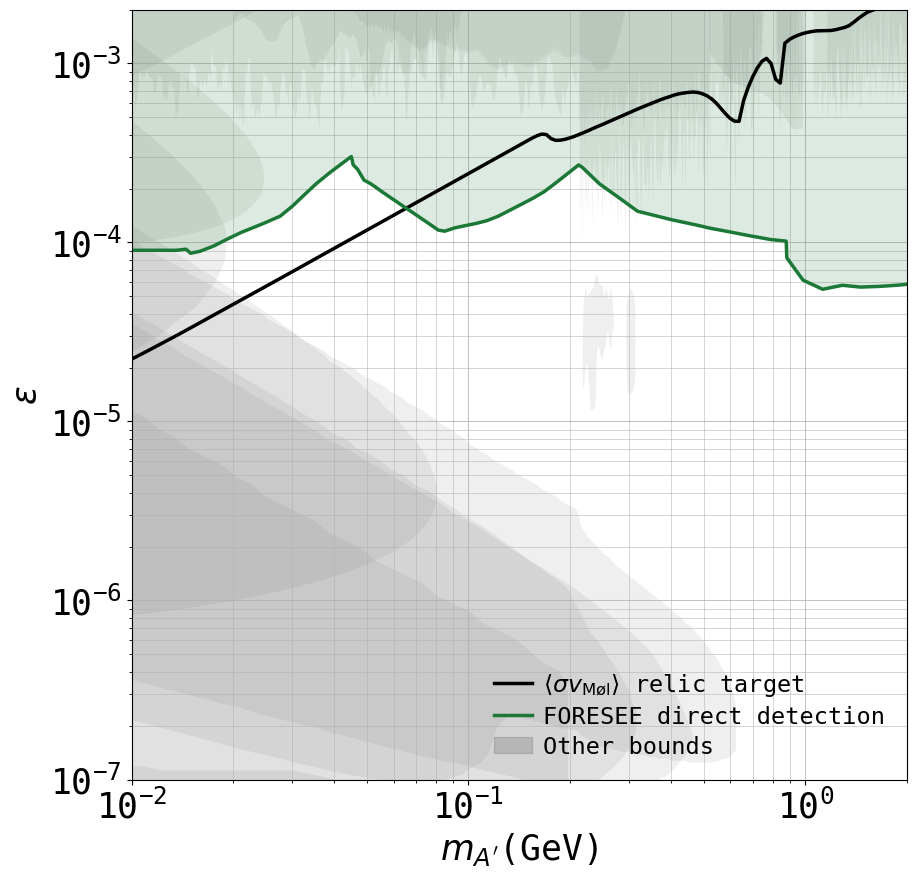

In [167]:
## Creating a plot:

fig, ax = plt.subplots(figsize=(10, 10))

ax.set_xlabel(r"$m_{A'}$(GeV)")
ax.set_ylabel(r"$\epsilon$")

## Log Axis
ax.set_xscale('log')
ax.set_yscale('log')

## Major grid:
ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.75)

## Minor ticks and grid:
ax.minorticks_on()
ax.grid(True, which='minor', linestyle='-', linewidth=0.5, alpha=0.75)

ax.set_axisbelow(True) # Ensure grid is below data

ax.plot(ma_relic_w, eps_relic_w, color = 'black', linewidth = 2.5,
        label = r"$\left\langle \sigma v_{\rm M\o l} \right\rangle$ relic target")

ax.plot(mlims, eplims, color = 'red', linewidth = 2.5)

ax.fill_between(mlims, eplims,
                1,
                color='red',
                alpha=0.15,
                zorder=1)

ax.plot(mlims_XENONnT, eplims_XENONnT,
        color = '#2a78d6', linewidth = 2.5)

ax.fill_between(mlims_XENONnT, eplims_XENONnT,
                1,
                color='#2a78d6',
                alpha=0.15,
                zorder=1)

# All sixteen shaded as one grey family: individually they would need
# sixteen legend entries and would bury the direct detection lines, and what
# matters here is only which part of the plane they already cover.
for _name, _b in bounds_lines.items():
    ax.fill(_b[:, 0], _b[:, 1], color = '#7e7e7e', alpha = 0.12,
            linewidth = 0, zorder = 0)

# One proxy handle for the family as a whole.
ax.fill(np.nan, np.nan, color = '#7e7e7e', alpha = 0.35,
        label = r"Other bounds")

ax.plot(ma_DD_kling_line, eps_DD_kling_line,
        color = '#1b7837', linewidth = 2.5, label = r"FORESEE direct detection")

ax.fill(ma_DD_kling, eps_DD_kling,
        color = '#1b7837',
        alpha = 0.15,
        zorder = 1)

## Setting a costumised legend:
handles, labels = ax.get_legend_handles_labels() # get all legend items
desired_order = [0,2,1]  # change the order of legend elements

ax.legend(
    [handles[i] for i in desired_order],
    [labels[i] for i in desired_order],
    loc = 'lower right',           # the lower right of the axes is empty
    ncol = 1,                      # stacked, to keep it narrow
    fontsize = 17,
    labelspacing = 0.3,
    handlelength = 1.6,
    handletextpad = 0.5,
    borderpad = 0.4,
    frameon = False                # removes legend border
)

# Define how much to zoom out from the data plotting range (cm):
x_min = 1e-2
x_max = 2e0

y_min = 1e-7
y_max = 2e-3

# Set the new plotting limits explicitly
ax.set_xbound(x_min, x_max)
ax.set_ybound(y_min, y_max)

# Save and show the figure:
plt.savefig("figures/relic_abundance_XENONnT_LZ.pdf", bbox_inches='tight')
plt.show()

## Breaking appart the direct detection line:

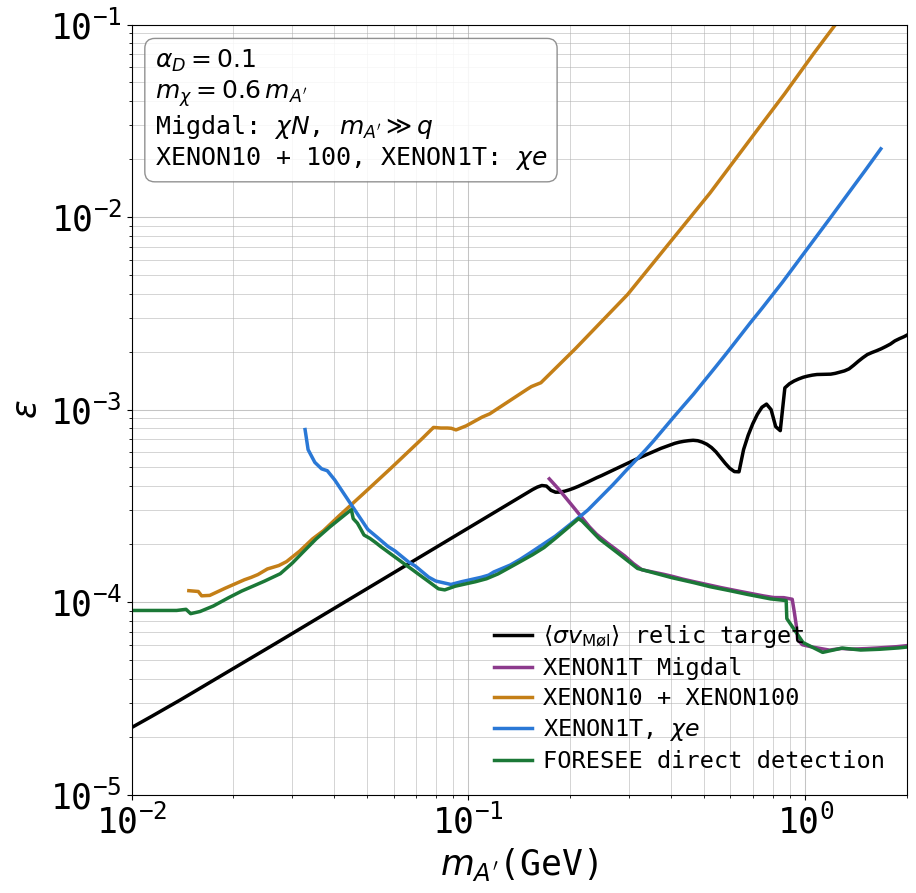

In [168]:
### The two DD_separate datasets that were reinterpreted for this model,
### against the contour Kling drew from them. Both are read at epsilon = 1
### and inverted, the Migdal one against the nucleon cross section and the
### electron recoil one against sig_si_theo_elec, so what is being compared
### is the reinterpretation itself: Kling's line is the same measurements
### passed through his own.

# Creating a plot:

fig, ax = plt.subplots(figsize=(10, 10))

ax.set_xlabel(r"$m_{A'}$(GeV)")
ax.set_ylabel(r"$\varepsilon$")

# Log Axis
ax.set_xscale('log')
ax.set_yscale('log')

# Major grid:
ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.75)

# Minor ticks and grid:
ax.minorticks_on()
ax.grid(True, which='minor', linestyle='-', linewidth=0.5, alpha=0.75)

ax.set_axisbelow(True) # Ensure grid is below data

# The relic target the limits are being set against.
ax.plot(ma_relic_w, eps_relic_w, color = 'black', linewidth = 2.5,
        label = r"$\left\langle \sigma v_{\rm M\o l} \right\rangle$ relic target")

# The nucleon reading, which lands on Kling's contour above 0.17 GeV.
ax.plot(mlims_migdal, eplims_migdal, color = '#8c3a8c', linewidth = 2.5,
        label = r"XENON1T Migdal")

# The electron reading, which covers the masses below that but stays above
# the contour everywhere, coming within 1.02 of it at m_A' = 0.037 GeV.
ax.plot(mlims_xe10and100, eplims_xe10and100, color = '#c47f17',
        linewidth = 2.5, label = r"XENON10 + XENON100")

# The XENON1T electron recoil limit, the one dataset here that cuts into the
# relic line, over m_A' = 0.067-0.317 GeV.
ax.plot(mlims_xe1t_e, eplims_xe1t_e, color = '#2a78d6', linewidth = 2.5,
        label = r"XENON1T, $\chi e$")

ax.plot(ma_DD_kling_line, eps_DD_kling_line, color = '#1b7837',
        linewidth = 2.5, label = r"FORESEE direct detection")

ax.text(0.03, 0.97,
        "\n".join([r"$\alpha_D = %g$" % alphaD,
                   r"$m_\chi = %g\, m_{A'}$" % mchi_over_ma,
                   r"Migdal: $\chi N$, $m_{A'} \gg q$",
                   r"XENON10 + 100, XENON1T: $\chi e$"]),
        transform = ax.transAxes, va = 'top', ha = 'left', fontsize = 18,
        bbox = dict(boxstyle = 'round,pad=0.4', facecolor = 'white',
                    edgecolor = '#7e7e7e', alpha = 0.85))

# Setting a costumised legend:
handles, labels = ax.get_legend_handles_labels() # get all legend items
desired_order = range(len(handles))  # change the order of legend elements

ax.legend(
    [handles[i] for i in desired_order],
    [labels[i] for i in desired_order],
    loc = 'lower right',           # the lower right of the axes is empty
    ncol = 1,                      # stacked, to keep it narrow
    fontsize = 17,
    labelspacing = 0.3,
    handlelength = 1.6,
    handletextpad = 0.5,
    borderpad = 0.4,
    frameon = False                # removes legend border
)

x_min = 1e-2
x_max = 2e0

y_min = 1e-5
y_max = 1e-1

ax.set_xbound(x_min, x_max)
ax.set_ybound(y_min, y_max)

# Save and show the figure:
plt.savefig("figures/direct_detection_breakdown.pdf", bbox_inches='tight')
plt.show()


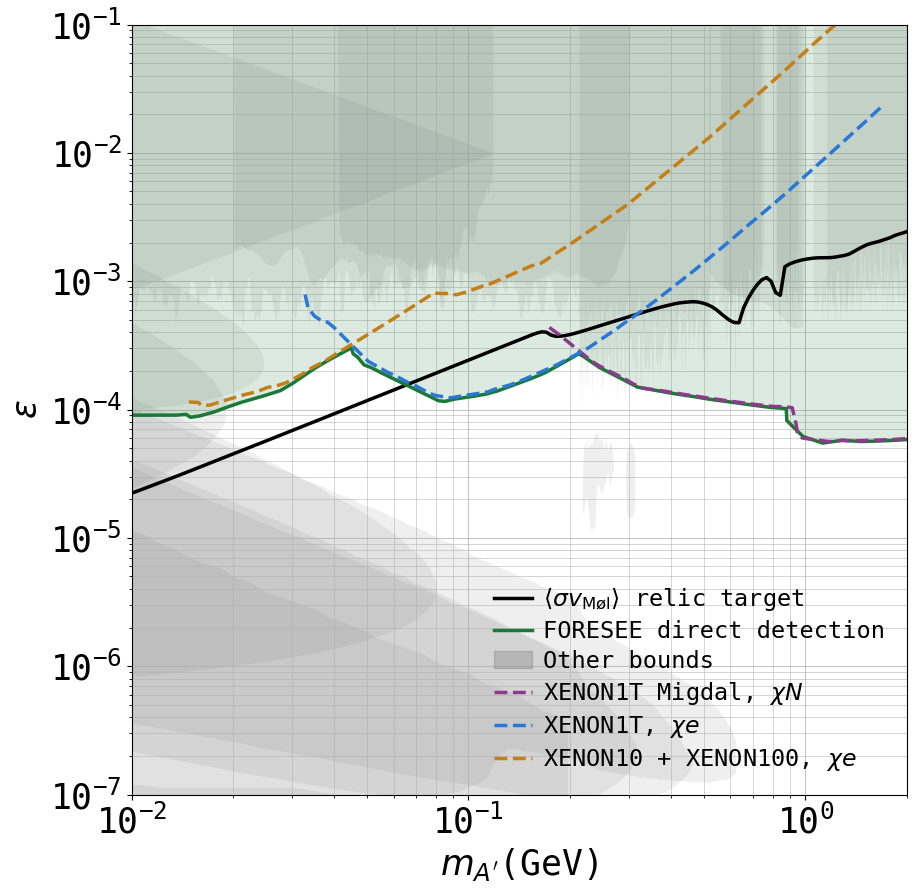

In [169]:
### The previous figure with the direct detection line broken open: the same
### relic target, accelerator and beam dump family and FORESEE contour, but
### with the three reinterpreted datasets drawn over the region they came
### from, so what the contour is made of can be read off the same axes as
### everything it is competing with.

## Creating a plot:

fig, ax = plt.subplots(figsize=(10, 10))

ax.set_xlabel(r"$m_{A'}$(GeV)")
ax.set_ylabel(r"$\epsilon$")

## Log Axis
ax.set_xscale('log')
ax.set_yscale('log')

## Major grid:
ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.75)

## Minor ticks and grid:
ax.minorticks_on()
ax.grid(True, which='minor', linestyle='-', linewidth=0.5, alpha=0.75)

ax.set_axisbelow(True) # Ensure grid is below data

ax.plot(ma_relic_w, eps_relic_w, color = 'black', linewidth = 2.5,
        label = r"$\left\langle \sigma v_{\rm M\o l} \right\rangle$ relic target")

ax.plot(mlims, eplims, color = 'red', linewidth = 2.5)

ax.fill_between(mlims, eplims,
                1,
                color='red',
                alpha=0.15,
                zorder=1)

ax.plot(mlims_XENONnT, eplims_XENONnT,
        color = '#2a78d6', linewidth = 2.5)

ax.fill_between(mlims_XENONnT, eplims_XENONnT,
                1,
                color='#2a78d6',
                alpha=0.15,
                zorder=1)

# All sixteen shaded as one grey family: individually they would need
# sixteen legend entries and would bury the direct detection lines, and what
# matters here is only which part of the plane they already cover.
for _name, _b in bounds_lines.items():
    ax.fill(_b[:, 0], _b[:, 1], color = '#7e7e7e', alpha = 0.12,
            linewidth = 0, zorder = 0)

# One proxy handle for the family as a whole.
ax.fill(np.nan, np.nan, color = '#7e7e7e', alpha = 0.35,
        label = r"Other bounds")

ax.plot(ma_DD_kling_line, eps_DD_kling_line,
        color = '#1b7837', linewidth = 2.5, label = r"FORESEE direct detection")

ax.fill(ma_DD_kling, eps_DD_kling,
        color = '#1b7837',
        alpha = 0.15,
        zorder = 1)

# The decomposition: the three datasets of the cell above, dashed so the
# contour they are being compared against stays the solid line. Only the
# XENON1T electron reading reaches below the relic target, and only over
# m_A' = 0.067-0.317 GeV.
ax.plot(mlims_migdal, eplims_migdal, color = '#8c3a8c', linestyle = '--',
        linewidth = 2.5, label = r"XENON1T Migdal, $\chi N$")

ax.plot(mlims_xe1t_e, eplims_xe1t_e, color = '#2a78d6', linestyle = '--',
        linewidth = 2.5, label = r"XENON1T, $\chi e$")

ax.plot(mlims_xe10and100, eplims_xe10and100, color = '#c47f17',
        linestyle = '--', linewidth = 2.5,
        label = r"XENON10 + XENON100, $\chi e$")

## Setting a costumised legend:
handles, labels = ax.get_legend_handles_labels() # get all legend items
desired_order = [0, 2, 1, 3, 4, 5]  # change the order of legend elements

ax.legend(
    [handles[i] for i in desired_order],
    [labels[i] for i in desired_order],
    loc = 'lower right',           # the lower right of the axes is empty
    ncol = 1,                      # stacked, to keep it narrow
    fontsize = 17,
    labelspacing = 0.3,
    handlelength = 1.6,
    handletextpad = 0.5,
    borderpad = 0.4,
    frameon = False                # removes legend border
)

# Define how much to zoom out from the data plotting range (cm):
x_min = 1e-2
x_max = 2e0

# The decomposition runs up to epsilon ~ 1e-2, an order of magnitude above
# the ceiling the previous figure used, so the window opens upwards.
y_min = 1e-7
y_max = 1e-1

# Set the new plotting limits explicitly
ax.set_xbound(x_min, x_max)
ax.set_ybound(y_min, y_max)

# Save and show the figure:
plt.savefig("figures/relic_abundance_decomposition.pdf", bbox_inches='tight')
plt.show()


## The current direct detection limits


In [170]:
### The current direct detection datasets, data/NewDD/.

# Each file pads the mass range it does not constrain with sigma = 1 cm^2, a
# sentinel that has to be masked or it interpolates as a real limit.

def read_alllimits(name, mass_scale):
    """Read a NewDD limit file, dropping the sigma = 1 padding, in (GeV, GeV^-2)."""
    d = np.loadtxt(f"data/NewDD/{name}")
    d = d[d[:, 1] < 1.0]
    return d[:, 0]*mass_scale, d[:, 1]*cm2_to_GeVm2

### DAMIC-M 2025, DAMIC-M_2025_Combined.txt: mchi in MeV, sigma_e in cm^2,
### the DAMIC-M result combined with its daily modulation search, 818 real
### points over 0.54-1000 MeV.

# It is the strongest electron recoil limit up to mchi = 37 MeV, above which
# XENON1T takes over; the two cross there, and by 1 GeV DAMIC-M is weaker by
# a factor 654.

mass_data_damic, sigmaedataGeV_damic = read_alllimits(
    "DAMIC-M_2025_Combined.txt", MeV_to_GeV)

mlims_damic, eplims_damic = eps_dd_limit(ma_dd, mchi_dd, mass_data_damic,
                                         sigmaedataGeV_damic,
                                         sigma_theo = sig_si_theo_elec)

### The 2024 electron envelope, AllLimits-2024_electrons_heavy_mediator.txt,
### drawn whole in the plot below before the decomposition.

# The F_DM = 1 quoting, the one this model needs: m_A' >= 10 MeV is four
# orders of magnitude above q ~ alpha m_e, so the rate is the contact one.
# It is the same quoting as the two files it is decomposed into below, which
# is what lets them lie on it. The folder's F_DM = (alpha m_e/q)^2 version of
# the same envelope is a factor ~1e3 weaker in sigma and belongs to the other
# regime, so it is left unread.

mass_data_all_e, sigmaedataGeV_all_e = read_alllimits(
    "AllLimits-2024_electrons_heavy_mediator.txt", MeV_to_GeV)

mlims_all_e, eplims_all_e = eps_dd_limit(ma_dd, mchi_dd, mass_data_all_e,
                                         sigmaedataGeV_all_e,
                                         sigma_theo = sig_si_theo_elec)

# AllLimits-2024_SI_nucleon.txt is left unread as well: the Migdal search is
# the stronger nucleon limit over the whole range plotted here and the only
# one below m_A' = 0.29 GeV.
### The experiments the electron envelope is built from,
### data/NewDD/Decomposition_e_light/.

# Sixteen files, all sigma_e in cm^2 against mchi in MeV. The folder is named
# _e_light but its contents are the F_DM = 1 quoting - several headers say so
# outright - and they reproduce the heavy mediator envelope, not the light
# one, so they are read as such.

# Four of them account for the envelope exactly: taking the minimum over
# SENSEI, DAMIC-M, DarkSide-50 and XENON1T reproduces it at every one of its
# 819 points to better than 2%. Dropping DarkSide-50 leaves 73 points
# unaccounted for over mchi = 25.7-50 MeV, and dropping SENSEI as well leaves
# 103 over 0.53-50 MeV, so DarkSide-50 is the file that completes the line.

# The aggregate is used rather than its pieces: DAMIC-M_2025 is DAMIC-M plus
# its daily modulation search, and only the combination touches the envelope.

def read_decomposition(name):
    """Read a Decomposition_e_light file, in (GeV, GeV^-2)."""
    d = np.genfromtxt(f"data/NewDD/Decomposition_e_light/{name}",
                      comments = "#")
    d = d[d[:, 1] < 1.0]
    d = d[np.argsort(d[:, 0])]
    return d[:, 0]*MeV_to_GeV, d[:, 1]*cm2_to_GeVm2

# SENSEI is left out: it owns the envelope only below mchi = 0.8 MeV, i.e.
# m_A' = 1.3 MeV, and the mass grid starts at m_A' = 10 MeV, so its curve
# never touches the line anywhere it can be seen.

decomposition_files = {
    "DAMIC-M 2025": "DAMIC-M_2025_Combined.txt",
    "DarkSide-50": "DarkSide-50.txt",
    "XENON1T": "XENON1T.txt",
}

decomposition = {name: eps_dd_limit(ma_dd, mchi_dd, *read_decomposition(f),
                                    sigma_theo = sig_si_theo_elec)
                 for name, f in decomposition_files.items()}


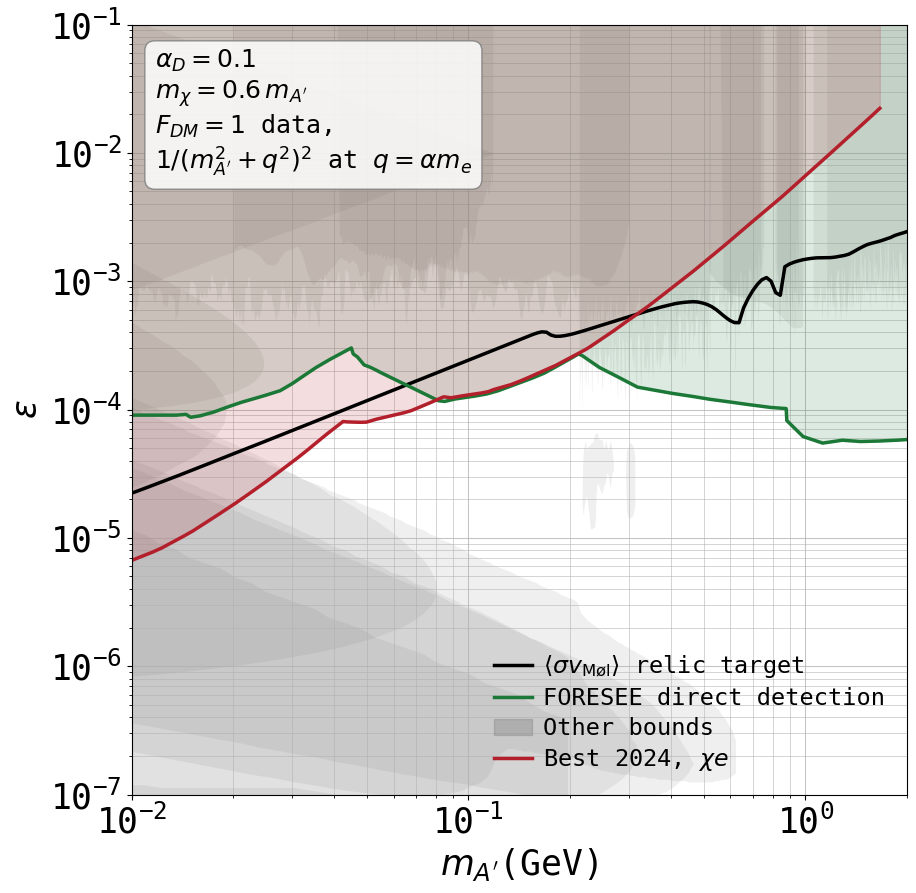

In [171]:
### The 2024 electron envelope as one line, before it is taken apart: the
### combined reach of every electron recoil search, against the relic target
### and the bounds already covering this plane.

## Creating a plot:

fig, ax = plt.subplots(figsize=(10, 10))

ax.set_xlabel(r"$m_{A'}$(GeV)")
ax.set_ylabel(r"$\epsilon$")

## Log Axis
ax.set_xscale('log')
ax.set_yscale('log')

## Major grid:
ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.75)

## Minor ticks and grid:
ax.minorticks_on()
ax.grid(True, which='minor', linestyle='-', linewidth=0.5, alpha=0.75)

ax.set_axisbelow(True) # Ensure grid is below data

ax.plot(ma_relic_w, eps_relic_w, color = 'black', linewidth = 2.5,
        label = r"$\left\langle \sigma v_{\rm M\o l} \right\rangle$ relic target")

# All sixteen shaded as one grey family: individually they would need
# sixteen legend entries and would bury the direct detection lines, and what
# matters here is only which part of the plane they already cover.
for _name, _b in bounds_lines.items():
    ax.fill(_b[:, 0], _b[:, 1], color = '#7e7e7e', alpha = 0.12,
            linewidth = 0, zorder = 0)

# One proxy handle for the family as a whole.
ax.fill(np.nan, np.nan, color = '#7e7e7e', alpha = 0.35,
        label = r"Other bounds")

ax.plot(ma_DD_kling_line, eps_DD_kling_line,
        color = '#1b7837', linewidth = 2.5, label = r"FORESEE direct detection")

ax.fill(ma_DD_kling, eps_DD_kling,
        color = '#1b7837',
        alpha = 0.15,
        zorder = 1)

ax.plot(mlims_all_e, eplims_all_e, color = '#b3202c', linewidth = 2.5,
        label = r"Best 2024, $\chi e$")

ax.fill_between(mlims_all_e, eplims_all_e, 1,
                color = '#b3202c', alpha = 0.15, zorder = 1)

ax.text(0.03, 0.97,
        "\n".join([r"$\alpha_D = %g$" % alphaD,
                   r"$m_\chi = %g\, m_{A'}$" % mchi_over_ma,
                   r"$F_{DM} = 1$ data,",
                   r"$1/(m_{A'}^2 + q^2)^2$ at $q = \alpha m_e$"]),
        transform = ax.transAxes, va = 'top', ha = 'left', fontsize = 18,
        bbox = dict(boxstyle = 'round,pad=0.4', facecolor = 'white',
                    edgecolor = '#7e7e7e', alpha = 0.85))

## Setting a costumised legend:
handles, labels = ax.get_legend_handles_labels() # get all legend items
desired_order = [0, 2, 1, 3]  # change the order of legend elements

ax.legend(
    [handles[i] for i in desired_order],
    [labels[i] for i in desired_order],
    loc = 'lower right',           # the lower right of the axes is empty
    ncol = 1,                      # stacked, to keep it narrow
    fontsize = 17,
    labelspacing = 0.3,
    handlelength = 1.6,
    handletextpad = 0.5,
    borderpad = 0.4,
    frameon = False                # removes legend border
)

# Define how much to zoom out from the data plotting range (cm):
x_min = 1e-2
x_max = 2e0

y_min = 1e-7
y_max = 1e-1

# Set the new plotting limits explicitly
ax.set_xbound(x_min, x_max)
ax.set_ybound(y_min, y_max)

# Save and show the figure:
plt.savefig("figures/relic_abundance_newDD.pdf", bbox_inches='tight')
plt.show()


### Decomposing it


### Who sets the 2024 electron line


| `mchi` | `m_A'` | experiment | reference |
|---|---|---|---|
| 0.80 - 25.5 MeV | 1.3 - 42.5 MeV | DAMIC-M + daily modulation | [2503.14617](https://arxiv.org/pdf/2503.14617), [2307.07251](https://arxiv.org/pdf/2307.07251), [2302.02372](https://arxiv.org/pdf/2302.02372) |
| 25.5 - 50.9 MeV | 42.5 - 84.8 MeV | DarkSide-50 | [2207.11968](https://arxiv.org/pdf/2207.11968) |
| above 50.9 MeV | above 84.8 MeV | XENON1T | [1907.11485](https://arxiv.org/pdf/1907.11485) |


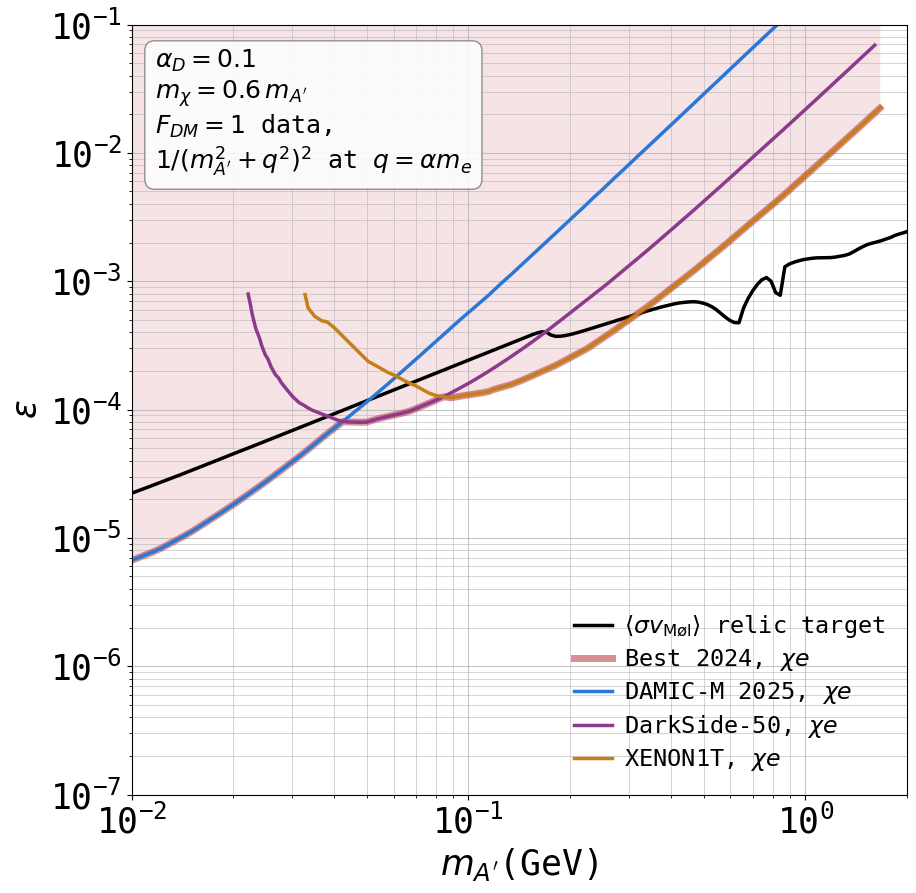

In [172]:
### The same line taken apart into the four experiments it is the minimum
### of, with everything that is not part of the decomposition dropped: the
### accelerator family, Kling's contour and the Migdal search are all still
### there, they just say nothing about which electron experiment sets which
### stretch of the line.

## Creating a plot:

fig, ax = plt.subplots(figsize=(10, 10))

ax.set_xlabel(r"$m_{A'}$(GeV)")
ax.set_ylabel(r"$\epsilon$")

## Log Axis
ax.set_xscale('log')
ax.set_yscale('log')

## Major grid:
ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.75)

## Minor ticks and grid:
ax.minorticks_on()
ax.grid(True, which='minor', linestyle='-', linewidth=0.5, alpha=0.75)

ax.set_axisbelow(True) # Ensure grid is below data

ax.plot(ma_relic_w, eps_relic_w, color = 'black', linewidth = 2.5,
        label = r"$\left\langle \sigma v_{\rm M\o l} \right\rangle$ relic target")

# The envelope of the cell above, for the components to be read against.
# Filled, because as a line alone it is hidden under the components that
# reproduce it: the shading is what makes its extent readable.
ax.plot(mlims_all_e, eplims_all_e, color = '#b3202c', linewidth = 5.0,
        alpha = 0.5, label = r"Best 2024, $\chi e$")

ax.fill_between(mlims_all_e, eplims_all_e, 1,
                color = '#b3202c', alpha = 0.12, linewidth = 0, zorder = 0)

# The three experiments that set it over the range plotted here: DAMIC-M to
# mchi = 25.5 MeV, DarkSide-50 to 50.9 MeV and XENON1T above. Where a curve
# lies on the red line, that experiment is the one setting the limit.
decomposition_colors = {"DAMIC-M 2025": '#2a78d6',
                        "DarkSide-50": '#8c3a8c',
                        "XENON1T": '#c47f17'}

for _name, (_m, _e) in decomposition.items():
    ax.plot(_m, _e, color = decomposition_colors[_name], linewidth = 2.5,
            label = rf"{_name}, $\chi e$")

ax.text(0.03, 0.97,
        "\n".join([r"$\alpha_D = %g$" % alphaD,
                   r"$m_\chi = %g\, m_{A'}$" % mchi_over_ma,
                   r"$F_{DM} = 1$ data,",
                   r"$1/(m_{A'}^2 + q^2)^2$ at $q = \alpha m_e$"]),
        transform = ax.transAxes, va = 'top', ha = 'left', fontsize = 18,
        bbox = dict(boxstyle = 'round,pad=0.4', facecolor = 'white',
                    edgecolor = '#7e7e7e', alpha = 0.85))

## Setting a costumised legend:
handles, labels = ax.get_legend_handles_labels() # get all legend items
desired_order = range(len(handles))  # change the order of legend elements

ax.legend(
    [handles[i] for i in desired_order],
    [labels[i] for i in desired_order],
    loc = 'lower right',           # the lower right of the axes is empty
    ncol = 1,                      # stacked, to keep it narrow
    fontsize = 17,
    labelspacing = 0.3,
    handlelength = 1.6,
    handletextpad = 0.5,
    borderpad = 0.4,
    frameon = False                # removes legend border
)

# Define how much to zoom out from the data plotting range (cm):
x_min = 1e-2
x_max = 2e0

y_min = 1e-7
y_max = 1e-1

# Set the new plotting limits explicitly
ax.set_xbound(x_min, x_max)
ax.set_ybound(y_min, y_max)

# Save and show the figure:
plt.savefig("figures/relic_abundance_newDD_decomposition.pdf",
            bbox_inches='tight')
plt.show()


## The final direct detection set

`data/Final DD/` holds the newest limits: `DAMIC-M_2025_Combined.txt`, which
is byte-identical to the copy already read from `data/NewDD/`, and
`Xenon_nT_light_2026.txt`, an XENONnT result not in any of the earlier
envelopes - [2601.11296](https://arxiv.org/pdf/2601.11296), figure 4.d, read
straight from its own header: `mchi` in GeV and `sigma_e` in cm^2, 36 points
over 0.040 - 9.90 GeV, most sensitive at `mchi` = 199 MeV where it reaches
6.6e-42 cm^2.

It supersedes the 2024 envelope everywhere the two overlap: it is stronger at
every one of the 23 shared points, by a median factor 17 in `sigma_e`
(ratio 0.060, range 0.040 - 0.080) over `mchi` = 40 - 930 MeV. The
decomposition of the previous section is therefore a decomposition of a line
that this result has already moved.

Against the model it is the strongest electron constraint yet: it excludes
the relic target over `m_A'` = 0.067 - 0.924 GeV, reaching a factor 10 below
it at `m_A'` = 0.127 GeV, and it carries the electron reach out to
`m_A'` = 16.5 GeV, well past the 1.67 GeV where XENON1T stops.


In [173]:
### XENONnT 2026, data/Final DD/Xenon_nT_light_2026.txt.

# arXiv:2601.11296 figure 4.d, mchi in GeV and sigma_e in cm^2, 36 points
# over 0.040-9.90 GeV. The two header lines carry no comment character, so
# they are skipped by count rather than by np.loadtxt's comments argument.

# This is the corrected digitisation; the .csv beside it is the earlier one,
# with the same sigma column against masses that were too high at the light
# end (it started at 0.44 GeV rather than 0.040), and is not read.

# It is stronger than the 2024 envelope at every point they share, by a
# median factor 17 in sigma, so it post-dates the decomposition rather than
# forming part of it and is drawn dashed.

data_xenonnt_2026 = np.loadtxt("data/Final DD/Xenon_nT_light_2026.txt",
                               delimiter = ",", skiprows = 2)

mass_data_xenonnt_2026 = data_xenonnt_2026[:, 0]
sigmaedataGeV_xenonnt_2026 = data_xenonnt_2026[:, 1] * cm2_to_GeVm2

mlims_xenonnt_2026, eplims_xenonnt_2026 = eps_dd_limit(
    ma_dd, mchi_dd, mass_data_xenonnt_2026, sigmaedataGeV_xenonnt_2026,
    sigma_theo = sig_si_theo_elec)

# data/Final DD/DAMIC-M_2025_Combined.txt is byte-identical to the copy in
# data/NewDD/ (same md5), so it is not read twice.
### PandaX-4T 2025, data/Final DD/PandaX4T2025.txt.

# arXiv:2507.11930 figure 4 top, the heavy mediator panel, 27 points over
# 51.5 MeV - 9.62 GeV, most sensitive at mchi = 204 MeV where it reaches
# 1.55e-41 cm^2. Same two unmarked header lines as the XENONnT file, but the
# masses are in MeV rather than GeV, so the header has to be read rather
# than assumed. It replaces Panda4X2023.txt, which is no longer in the folder.

data_panda = np.loadtxt("data/Final DD/PandaX4T2025.txt", delimiter = ",",
                        skiprows = 2)

mass_data_panda = data_panda[:, 0]*MeV_to_GeV
sigmaedataGeV_panda = data_panda[:, 1] * cm2_to_GeVm2

mlims_panda, eplims_panda = eps_dd_limit(
    ma_dd, mchi_dd, mass_data_panda, sigmaedataGeV_panda,
    sigma_theo = sig_si_theo_elec)

### PandaX-4T S2, recast for CEvNS,
### data/Final DD/PandaX4TS2_2025_CEnuNS.txt.

# arXiv:2507.15956 figure 2 left, mchi in MeV and sigma_e in cm^2, 45 points
# over 20.0-894 MeV, most sensitive at mchi = 166 MeV where it reaches
# 1.87e-41 cm^2. One pair of rows is out of order, so the file is sorted on
# load; the rest is a single monotonic pass.

# This one does set part of the line. It is below DarkSide-50 at all 45 of
# its points, by a median factor 0.060, and it reaches down to 20 MeV, so it
# takes over the 21-40 MeV that DarkSide-50 held and displaces it from the
# combination entirely. Above 40 MeV XENONnT is still lower, by a median
# factor 2.8.

data_cenuns = np.loadtxt("data/Final DD/PandaX4TS2_2025_CEnuNS.txt",
                         delimiter = ",", skiprows = 2)
data_cenuns = data_cenuns[np.argsort(data_cenuns[:, 0])]

mass_data_cenuns = data_cenuns[:, 0]*MeV_to_GeV
sigmaedataGeV_cenuns = data_cenuns[:, 1] * cm2_to_GeVm2

mlims_cenuns, eplims_cenuns = eps_dd_limit(
    ma_dd, mchi_dd, mass_data_cenuns, sigmaedataGeV_cenuns,
    sigma_theo = sig_si_theo_elec)

### The 2026 combination: the same construction as the 2024 envelope, with
### XENONnT and the two PandaX-4T results folded in.

# The published envelope stops at 2024, so the current best line has to be
# built here: the minimum in sigma_e over the four experiments that make up
# the 2024 envelope plus XENONnT 2026, on a common log grid spanning them.

# XENON1T, PandaX-4T 2025 and DarkSide-50 are carried in the minimum for
# completeness even though none of them wins any longer: XENONnT is below
# XENON1T and PandaX-4T at every shared mass, and the CEvNS recast is below
# DarkSide-50 at every one of its. The line is SENSEI up to mchi = 0.80 MeV,
# DAMIC-M to 21.1 MeV, the CEvNS recast to 40.5 MeV and XENONnT above.

best2026_parts = {name: read_decomposition(f)
                  for name, f in decomposition_files.items()}
best2026_parts["SENSEI"] = read_decomposition("SENSEI_2024_Combined.txt")
best2026_parts["XENONnT 2026"] = (mass_data_xenonnt_2026,
                                  sigmaedataGeV_xenonnt_2026)
best2026_parts["PandaX-4T 2025"] = (mass_data_panda, sigmaedataGeV_panda)
best2026_parts["PandaX-4T S2 CEvNS"] = (mass_data_cenuns,
                                        sigmaedataGeV_cenuns)

_lo = min(m.min() for m, _ in best2026_parts.values())
_hi = max(m.max() for m, _ in best2026_parts.values())

mass_data_best2026 = np.logspace(np.log10(_lo), np.log10(_hi), 2000)

# Each limit only covers part of the grid, so the ones that do not reach a
# given mass are set to infinity rather than extrapolated: np.interp would
# otherwise clamp them flat and let a curve win where it has no data.
_stack = []
for _m, _s in best2026_parts.values():
    _col = np.full_like(mass_data_best2026, np.inf)
    _in = (mass_data_best2026 >= _m.min()) & (mass_data_best2026 <= _m.max())
    _col[_in] = np.exp(np.interp(np.log(mass_data_best2026[_in]),
                                 np.log(_m), np.log(_s)))
    _stack.append(_col)

sigmaedataGeV_best2026 = np.min(_stack, axis = 0)

_covered = np.isfinite(sigmaedataGeV_best2026)
mass_data_best2026 = mass_data_best2026[_covered]
sigmaedataGeV_best2026 = sigmaedataGeV_best2026[_covered]

mlims_best2026, eplims_best2026 = eps_dd_limit(
    ma_dd, mchi_dd, mass_data_best2026, sigmaedataGeV_best2026,
    sigma_theo = sig_si_theo_elec)
### DarkSide-50 Migdal, data/Final DD/DarkSide50-Migdal-2023.txt.

# arXiv:2207.11967 figure 3, mchi in GeV and sigma_SI in cm^2, 50 points over
# 0.039-9.71 GeV. A nucleon limit, not an electron one, so it goes with the
# XENON1T Migdal search rather than into the electron combination and is read
# against the default sig_si_theo.

# It is the stronger of the two Migdal searches over mchi = 0.105-0.494 GeV,
# by up to a factor 21 at 0.11 GeV, and weaker above that, by 4.8 at 1 GeV
# rising to 8.4 at 4 GeV. It also reaches further at both ends: XENON1T
# Migdal covers 0.104-4.91 GeV, this one 0.039-9.71 GeV. Together they
# exclude the relic target over m_A' = 0.065-16.2 GeV.

data_ds50_migdal = np.loadtxt("data/Final DD/DarkSide50-Migdal-2023.txt",
                              delimiter = ",", skiprows = 2)

mass_data_ds50_migdal = data_ds50_migdal[:, 0]
sigmasidataGeV_ds50_migdal = data_ds50_migdal[:, 1] * cm2_to_GeVm2

mlims_ds50_migdal, eplims_ds50_migdal = eps_dd_limit(
    ma_dd, mchi_dd, mass_data_ds50_migdal, sigmasidataGeV_ds50_migdal)
### The full 2026 line, electron and nucleon together.

# The two targets cannot be combined in sigma - sigma_e and sigma_SI are not
# the same quantity - so the combination is done in epsilon, where both have
# already been mapped onto the same model. At each m_A' the bound is whichever
# search gives the smallest epsilon.

def eps_on_ma_dd(ma_valid, eps_valid):
    """An eps_dd_limit result placed on the full ma_dd grid, inf where unset."""
    out = np.full_like(ma_dd, np.inf)
    inside = (ma_dd >= ma_valid.min()) & (ma_dd <= ma_valid.max())
    out[inside] = np.exp(np.interp(np.log(ma_dd[inside]),
                                   np.log(ma_valid), np.log(eps_valid)))
    return out

eps_best2026_all = np.min([eps_on_ma_dd(mlims_best2026, eplims_best2026),
                           eps_on_ma_dd(mlims_migdal, eplims_migdal),
                           eps_on_ma_dd(mlims_ds50_migdal, eplims_ds50_migdal)],
                          axis = 0)

_covered_all = np.isfinite(eps_best2026_all)

mlims_best2026_all = ma_dd[_covered_all]
eplims_best2026_all = eps_best2026_all[_covered_all]


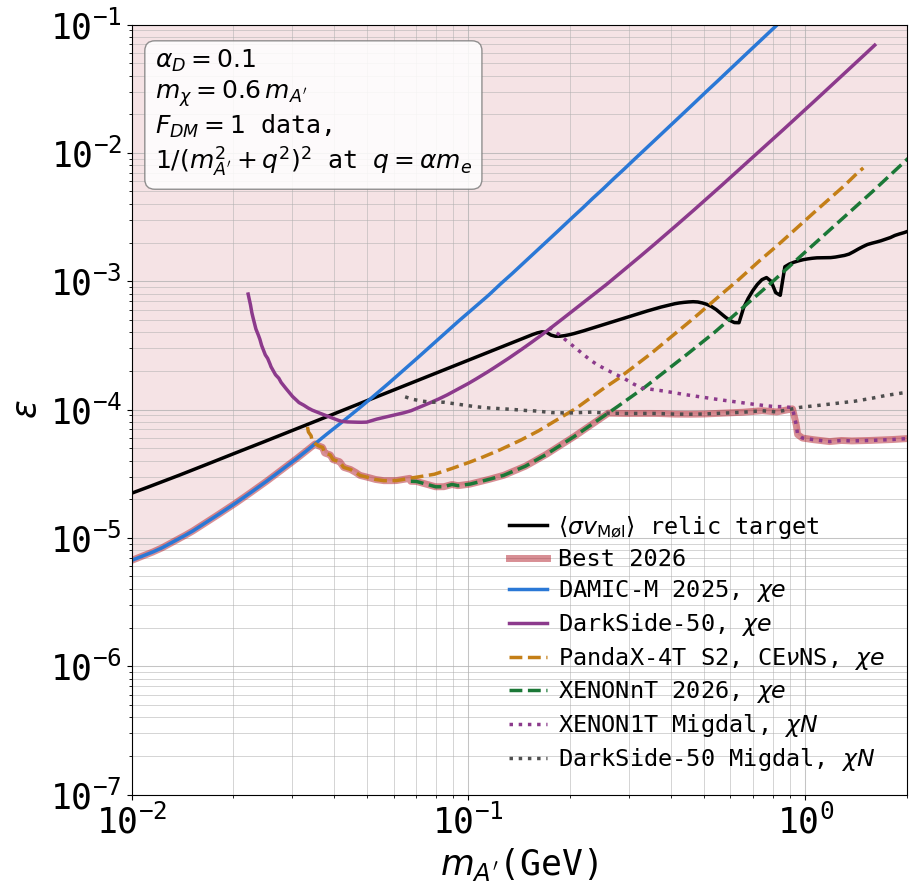

In [174]:
### The current best line, electron and nucleon, and the experiments it is
### made of. The
### 2024 envelope is replaced by the 2026 combination, which is the same
### minimum with XENONnT folded in; XENON1T is dropped, since XENONnT is
### below it at every mass they share and it no longer sets any part of the
### line. What is left is DAMIC-M, DarkSide-50 and XENONnT, and only the
### last of them excludes the relic target.

## Creating a plot:

fig, ax = plt.subplots(figsize=(10, 10))

ax.set_xlabel(r"$m_{A'}$(GeV)")
ax.set_ylabel(r"$\epsilon$")

## Log Axis
ax.set_xscale('log')
ax.set_yscale('log')

## Major grid:
ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.75)

## Minor ticks and grid:
ax.minorticks_on()
ax.grid(True, which='minor', linestyle='-', linewidth=0.5, alpha=0.75)

ax.set_axisbelow(True) # Ensure grid is below data

ax.plot(ma_relic_w, eps_relic_w, color = 'black', linewidth = 2.5,
        label = r"$\left\langle \sigma v_{\rm M\o l} \right\rangle$ relic target")

# The current best line, for the components to be read against. Filled,
# because as a line alone it is hidden under the components that reproduce
# it: the shading is what makes its extent readable.
ax.plot(mlims_best2026_all, eplims_best2026_all, color = '#b3202c',
        linewidth = 5.0, alpha = 0.5, label = r"Best 2026")

ax.fill_between(mlims_best2026_all, eplims_best2026_all, 1,
                color = '#b3202c', alpha = 0.12, linewidth = 0, zorder = 0)

# The three experiments that set it over the range plotted here: DAMIC-M to
# mchi = 25.5 MeV, DarkSide-50 to 50.9 MeV and XENON1T above. Where a curve
# lies on the red line, that experiment is the one setting the limit.
decomposition_colors = {"DAMIC-M 2025": '#2a78d6',
                        "DarkSide-50": '#8c3a8c',
                        "XENON1T": '#c47f17'}

# XENON1T is dropped here: XENONnT is stronger at every mass the two share,
# by a median factor 17 in sigma, so it no longer sets any part of the line.
# The 19.6-40.4 MeV where XENON1T reaches and XENONnT does not is DarkSide-50
# territory anyway, so nothing is left uncovered.
for _name, (_m, _e) in decomposition.items():
    if _name == "XENON1T":
        continue

    ax.plot(_m, _e, color = decomposition_colors[_name], linewidth = 2.5,
            label = rf"{_name}, $\chi e$")

# The two results that post-date the 2024 envelope and set part of the line,
# dashed to separate them from the experiments that reproduce it. PandaX-4T
# 2025 is not drawn: XENONnT is below it everywhere and it sets nothing.
ax.plot(mlims_cenuns, eplims_cenuns, color = '#c47f17', linestyle = '--',
        linewidth = 2.5, label = r"PandaX-4T S2, CE$\nu$NS, $\chi e$")

ax.plot(mlims_xenonnt_2026, eplims_xenonnt_2026, color = '#1b7837',
        linestyle = '--', linewidth = 2.5,
        label = r"XENONnT 2026, $\chi e$")

# The nucleon side, dotted: two Migdal searches that trade places at
# mchi = 0.5 GeV, and together own the line above m_A' = 1 GeV.
ax.plot(mlims_migdal, eplims_migdal, color = '#8c3a8c', linestyle = ':',
        linewidth = 2.5, label = r"XENON1T Migdal, $\chi N$")

ax.plot(mlims_ds50_migdal, eplims_ds50_migdal, color = '#4e4e4e',
        linestyle = ':', linewidth = 2.5,
        label = r"DarkSide-50 Migdal, $\chi N$")

ax.text(0.03, 0.97,
        "\n".join([r"$\alpha_D = %g$" % alphaD,
                   r"$m_\chi = %g\, m_{A'}$" % mchi_over_ma,
                   r"$F_{DM} = 1$ data,",
                   r"$1/(m_{A'}^2 + q^2)^2$ at $q = \alpha m_e$"]),
        transform = ax.transAxes, va = 'top', ha = 'left', fontsize = 18,
        bbox = dict(boxstyle = 'round,pad=0.4', facecolor = 'white',
                    edgecolor = '#7e7e7e', alpha = 0.85))

## Setting a costumised legend:
handles, labels = ax.get_legend_handles_labels() # get all legend items
desired_order = range(len(handles))  # change the order of legend elements

ax.legend(
    [handles[i] for i in desired_order],
    [labels[i] for i in desired_order],
    loc = 'lower right',           # the lower right of the axes is empty
    ncol = 1,                      # stacked, to keep it narrow
    fontsize = 17,
    labelspacing = 0.3,
    handlelength = 1.6,
    handletextpad = 0.5,
    borderpad = 0.4,
    frameon = False                # removes legend border
)

# Define how much to zoom out from the data plotting range (cm):
x_min = 1e-2
x_max = 2e0                       

y_min = 1e-7
y_max = 1e-1

# Set the new plotting limits explicitly
ax.set_xbound(x_min, x_max)
ax.set_ybound(y_min, y_max)

# Save and show the figure:
plt.savefig("figures/relic_abundance_finalDD.pdf", bbox_inches='tight')
plt.show()


## The current picture


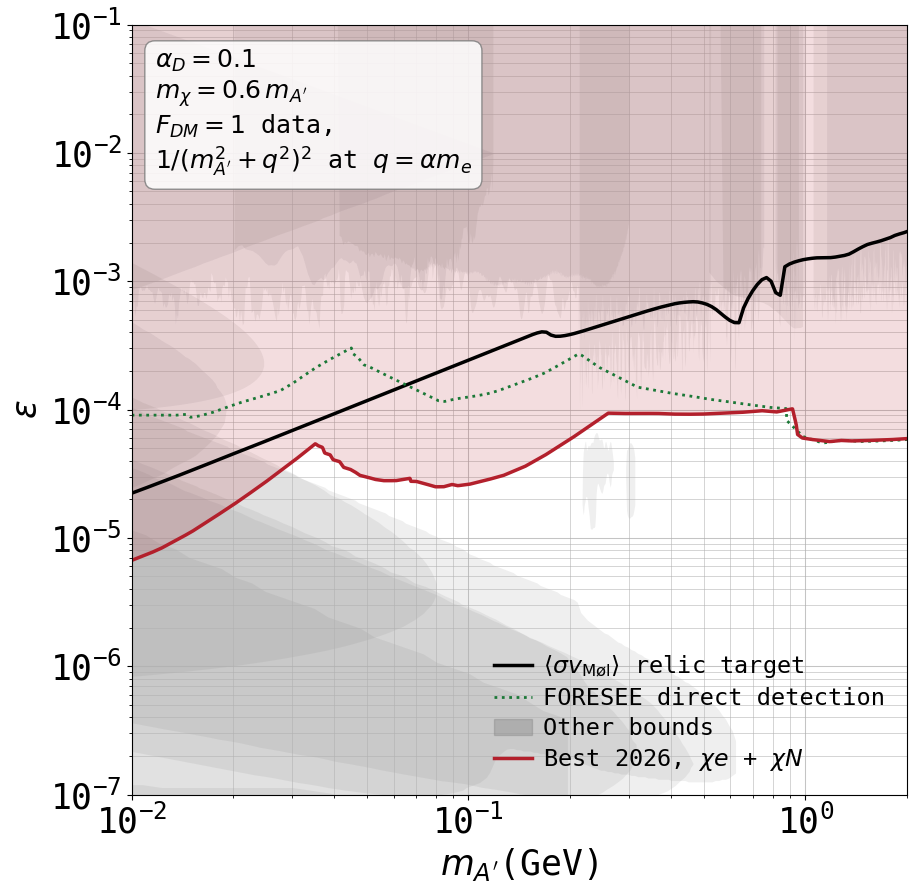

In [175]:
### The FORESEE figure with the current direct detection line in place of
### Kling's: same relic target, same bound family, same framing.

## Creating a plot:

fig, ax = plt.subplots(figsize=(10, 10))

ax.set_xlabel(r"$m_{A'}$(GeV)")
ax.set_ylabel(r"$\epsilon$")

## Log Axis
ax.set_xscale('log')
ax.set_yscale('log')

## Major grid:
ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.75)

## Minor ticks and grid:
ax.minorticks_on()
ax.grid(True, which='minor', linestyle='-', linewidth=0.5, alpha=0.75)

ax.set_axisbelow(True) # Ensure grid is below data

ax.plot(ma_relic_w, eps_relic_w, color = 'black', linewidth = 2.5,
        label = r"$\left\langle \sigma v_{\rm M\o l} \right\rangle$ relic target")

# All sixteen shaded as one grey family: individually they would need
# sixteen legend entries and would bury the direct detection lines, and what
# matters here is only which part of the plane they already cover.
for _name, _b in bounds_lines.items():
    ax.fill(_b[:, 0], _b[:, 1], color = '#7e7e7e', alpha = 0.12,
            linewidth = 0, zorder = 0)

# One proxy handle for the family as a whole.
ax.fill(np.nan, np.nan, color = '#7e7e7e', alpha = 0.35,
        label = r"Other bounds")

# Kling's contour, kept as the thing being superseded rather than as a bound.
ax.plot(ma_DD_kling_line, eps_DD_kling_line, color = '#1b7837',
        linewidth = 2.0, linestyle = ':',
        label = r"FORESEE direct detection")

# The 2026 line, electron and nucleon searches taken together: one curve,
# undecomposed, which experiment owns which stretch is the section above.
ax.plot(mlims_best2026_all, eplims_best2026_all, color = '#b3202c',
        linewidth = 2.5, label = r"Best 2026, $\chi e$ + $\chi N$")

ax.fill_between(mlims_best2026_all, eplims_best2026_all, 1,
                color = '#b3202c', alpha = 0.15, zorder = 1)

ax.text(0.03, 0.97,
        "\n".join([r"$\alpha_D = %g$" % alphaD,
                   r"$m_\chi = %g\, m_{A'}$" % mchi_over_ma,
                   r"$F_{DM} = 1$ data,",
                   r"$1/(m_{A'}^2 + q^2)^2$ at $q = \alpha m_e$"]),
        transform = ax.transAxes, va = 'top', ha = 'left', fontsize = 18,
        bbox = dict(boxstyle = 'round,pad=0.4', facecolor = 'white',
                    edgecolor = '#7e7e7e', alpha = 0.85))

## Setting a costumised legend:
handles, labels = ax.get_legend_handles_labels() # get all legend items
desired_order = [0, 2, 1, 3]  # change the order of legend elements

ax.legend(
    [handles[i] for i in desired_order],
    [labels[i] for i in desired_order],
    loc = 'lower right',           # the lower right of the axes is empty
    ncol = 1,                      # stacked, to keep it narrow
    fontsize = 17,
    labelspacing = 0.3,
    handlelength = 1.6,
    handletextpad = 0.5,
    borderpad = 0.4,
    frameon = False                # removes legend border
)

# Define how much to zoom out from the data plotting range (cm):
x_min = 1e-2
x_max = 2e0

y_min = 1e-7
y_max = 1e-1

# Set the new plotting limits explicitly
ax.set_xbound(x_min, x_max)
ax.set_ybound(y_min, y_max)

# Save and show the figure:
plt.savefig("figures/relic_abundance_best2026.pdf", bbox_inches='tight')
plt.show()


### Range of target lines in parameters for parameters

## The relic line at other parameters

The baseline sits above the current bound everywhere, so the model only
survives at parameters that push the relic line down. Both levers do that:
`eps` goes as `1/sqrt(alpha_D)`, and `mchi/mA'` approaching 0.5 from above
brings the annihilation threshold `sqrt(s) = 2 mchi` down onto the `A'` pole,
enhancing the cross section. The three ladders below were generated with

    python3 moller_scan.py --min-mass 0.01 --max-mass 20 --points 300 \
        --alpha-d <alphaD> --mchi-over-ma <r> --output data/<file>.csv

and stop at `mchi/mA' = 0.51`, where the threshold is still 2% above the
pole.


In [176]:
### The relic line at three further parameter points, for comparison with
### the baseline. Each file carries its own alphaD and mchi/mA' in its header
### comments, so the labels are read back out rather than typed in.

relic_ladder_files = [
    ("data/moller_relic_line_wide.csv", '#000000'),
    ("data/moller_relic_line_aD0.3_r0.55.csv", '#2a78d6'),
    ("data/moller_relic_line_aD0.5_r0.53.csv", '#1b7837'),
    ("data/moller_relic_line_aD0.9_r0.51.csv", '#8c3a8c'),
]

relic_ladder = [(*read_relic_csv(f), color) for f, color in relic_ladder_files]

# Each rung is below the one above it at every mass they share, medians 0.34,
# 0.54 and 0.38 against the preceding rung and 0.072 for the last against the
# baseline, so the ladder never crosses itself.


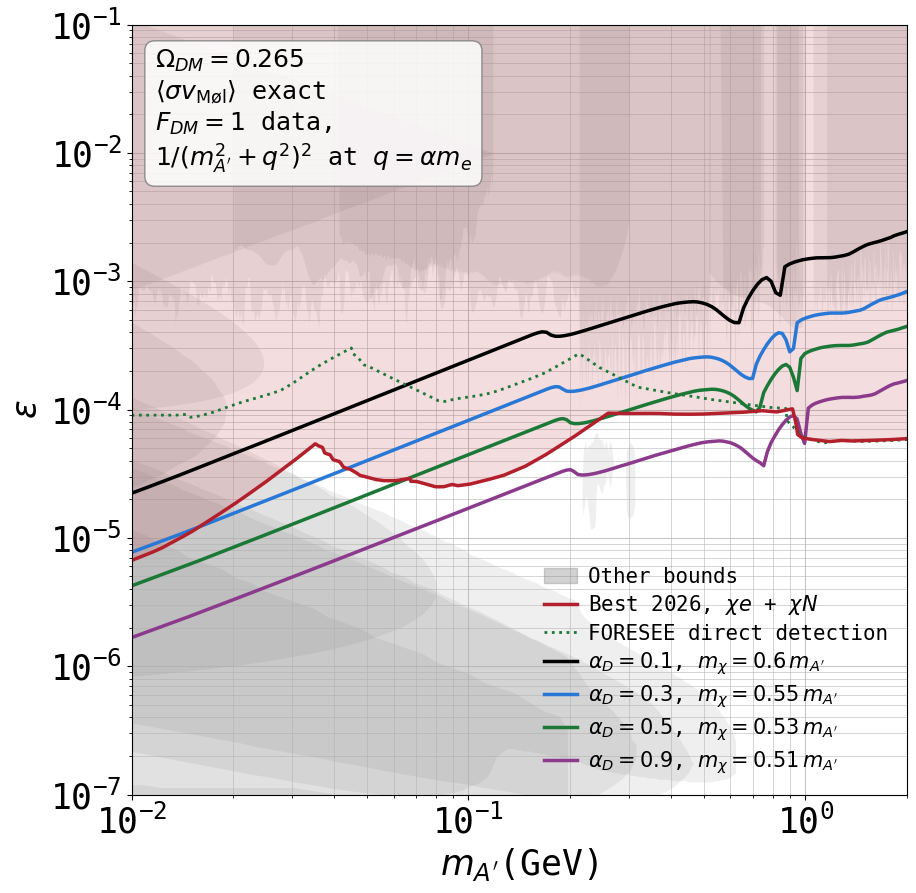

In [177]:
### The same figure with the relic target replaced by the ladder: one line
### per (alpha_D, mchi/mA') pair, against the one direct detection line. What
### is being read off is how far the parameters have to move before the relic
### line clears the bound.

## Creating a plot:

fig, ax = plt.subplots(figsize=(10, 10))

ax.set_xlabel(r"$m_{A'}$(GeV)")
ax.set_ylabel(r"$\epsilon$")

## Log Axis
ax.set_xscale('log')
ax.set_yscale('log')

## Major grid:
ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.75)

## Minor ticks and grid:
ax.minorticks_on()
ax.grid(True, which='minor', linestyle='-', linewidth=0.5, alpha=0.75)

ax.set_axisbelow(True) # Ensure grid is below data

for _ma, _eps, _meta, _color in relic_ladder:
    ax.plot(_ma, _eps, color = _color, linewidth = 2.5,
            label = r"$\alpha_D = %s$, $m_\chi = %s\, m_{A'}$"
                    % (_meta["alphaD"], _meta["mchi_over_ma"]))

# All sixteen shaded as one grey family: individually they would need
# sixteen legend entries and would bury the direct detection lines, and what
# matters here is only which part of the plane they already cover.
for _name, _b in bounds_lines.items():
    ax.fill(_b[:, 0], _b[:, 1], color = '#7e7e7e', alpha = 0.12,
            linewidth = 0, zorder = 0)

# One proxy handle for the family as a whole.
ax.fill(np.nan, np.nan, color = '#7e7e7e', alpha = 0.35,
        label = r"Other bounds")

# Kling's contour, kept as the thing being superseded rather than as a bound.
ax.plot(ma_DD_kling_line, eps_DD_kling_line, color = '#1b7837',
        linewidth = 2.0, linestyle = ':',
        label = r"FORESEE direct detection")

# The 2026 line, electron and nucleon searches taken together: one curve,
# undecomposed, which experiment owns which stretch is the section above.
ax.plot(mlims_best2026_all, eplims_best2026_all, color = '#b3202c',
        linewidth = 2.5, label = r"Best 2026, $\chi e$ + $\chi N$")

ax.fill_between(mlims_best2026_all, eplims_best2026_all, 1,
                color = '#b3202c', alpha = 0.15, zorder = 1)

ax.text(0.03, 0.97,
        "\n".join([r"$\Omega_{DM} = %s$" % relic_ladder[0][2]["Omega_target"],
                   r"$\left\langle \sigma v_{\rm M\o l} \right\rangle$ exact",
                   r"$F_{DM} = 1$ data,",
                   r"$1/(m_{A'}^2 + q^2)^2$ at $q = \alpha m_e$"]),
        transform = ax.transAxes, va = 'top', ha = 'left', fontsize = 18,
        bbox = dict(boxstyle = 'round,pad=0.4', facecolor = 'white',
                    edgecolor = '#7e7e7e', alpha = 0.85))

## Setting a costumised legend:
handles, labels = ax.get_legend_handles_labels() # get all legend items
desired_order = [4, 6, 5, 0, 1, 2, 3]  # change the order of legend elements

ax.legend(
    [handles[i] for i in desired_order],
    [labels[i] for i in desired_order],
    loc = 'lower right',           # the lower right of the axes is empty
    ncol = 1,                      # stacked, to keep it narrow
    fontsize = 15,
    labelspacing = 0.3,
    handlelength = 1.6,
    handletextpad = 0.5,
    borderpad = 0.4,
    frameon = False                # removes legend border
)

# Define how much to zoom out from the data plotting range (cm):
x_min = 1e-2
x_max = 2e0

y_min = 1e-7
y_max = 1e-1

# Set the new plotting limits explicitly
ax.set_xbound(x_min, x_max)
ax.set_ybound(y_min, y_max)

# Save and show the figure:
plt.savefig("figures/relic_abundance_ladder.pdf", bbox_inches='tight')
plt.show()
